# DSN BOOTCAMP 2026 ML Track hackathon catboost single model sqrt transform 



## Phase 1: Importing needed Libraries and Dataset

In [61]:
%pip install -q xgboost catboost lightgbm
# set USE_MLFLOW = True below and uncomment this if you want experiment tracking back
# %pip install -q dagshub mlflow

Note: you may need to restart the kernel to use updated packages.


In [62]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
import optuna
import lightgbm as lgb

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import KFold


# flip this on if you want the mlflow/dagshub experiment tracking from the original
# notebook back - evaluate_model() below already has the logging calls, just gated
# behind this flag so the notebook runs standalone without dagshub auth
USE_MLFLOW = False
if USE_MLFLOW:
    import mlflow
    import dagshub
    # Initialize dagshub for experiment-tracking 
    dagshub.init(repo_owner='Metro', repo_name='DSN-hackathon-2026', mlflow=True)
    mlflow.set_experiment("mean_fillnav0.1.1experiment")

In [63]:
# Global variables
RANDOM_SEED = 43
TARGET = "total_sales"

# major directory file_path.
DIR = "/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/"

# specific filepaths
train_path = f"{DIR}train.csv"
test_path = f"{DIR}test.csv"
sample_path = f"{DIR}sample_submission.csv"

# importing the files using pandas read_csv
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)


In [64]:
# check the data
# Hide this 
def basic_data(df: pd.DataFrame, name: str, for_y = 0):
    """
    function prints the shape of the data
    """
    if for_y == 0:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows and {shape[1]} Columns")
        print('*'* 30)
    else:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows")
        print('*'* 30)


def check_nan_state(df, name):
    """
    output the percentage of nan in each column
    """
    total_rows = len(df)
    if total_rows == 0:
        print("Dataframe is empty !!!")
    else:
        nan_percent = (df.isna().sum()/ total_rows * 100).round(2)
        nan_percent_display = pd.DataFrame({"Column" : nan_percent.index,
                                            "Percent missing" : nan_percent.values}).sort_values("Percent missing"
                                                                                                 , ascending = False)
        print(f"Percent values of NAN values in {name} dataframe ")
        display(nan_percent_display)



In [65]:
basic_data(train, "train")
basic_data(test, "test")
basic_data(sample, "sample_submission")

The train dataframe has 6818 Rows and 13 Columns
******************************
The test dataframe has 1705 Rows and 12 Columns
******************************
The sample_submission dataframe has 1705 Rows and 2 Columns
******************************


### Description of the columns in the train data 
|column|Description|
|------|-----------|
|id| Unique row identifier|
| product_code| Unique code for the product|
|product_weight_kg |	Weight of the product in kilograms (some values are missing)|
|fat_content |	Whether the product is labelled "Low Fat" or "Regular"|
|shelf_visibility |	The proportion of total display area in the store allocated to this product|
|product_category |	The product's category (note: capitalization is inconsistent — that's real-world data, not a bug)|
|product_price |	The product's listed price|
|store_code |	Unique code for the store|
|store_size |	The store's size category: Small, Medium, or Large (some values are missing)|
|store_location_tier |	The tier of the store's location — Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns)|
|store_format |	The store's format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket|
|total_sales |	Target. Total sales value for this product at this store (train only)|

## Phase 2: Simple Exploratory data Analysis

In [66]:
# check out the train data 
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [67]:
check_nan_state(train, "train")

Percent values of NAN values in train dataframe 


,Column,Percent missing
9,store_size,28.15
2,product_weight_kg,17.97
0,id,0.00
3,fat_content,0.00
1,product_code,0.00
4,shelf_visibility,0.00
5,product_category,0.00
7,store_code,0.00
6,product_price,0.00
8,store_age_years,0.00


In [68]:
# check out the statistical distribution of the numerical columns in the df
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


notice that spike from 75% percentile total sales of 3k to 100% percentile total sales of 12k some thing is there

- the 12k total sales is  under `HOUSEHOLD`, `fruitsandvegitables` in product_category
- we also have 10k total sales under `Dairy` in the product_category i would do a more indepth search on this spike it might be outliers

now checking from store formats this follows normal conventions 
|store_format|   total_sales |
|------------|------------------|
|Corner Shop  |            1830.37|
|Flagship Hypermarket |   12996.82|
|Standard Supermarket |   10130.90|
|Superstore          |     7016.22|


In [69]:
total_sales_groupby = train.groupby("product_category")["total_sales"].max()
total_sales_groupby

product_category
BAKING GOODS              7720.12
BREADS                    5897.21
BREAKFAST                 7125.94
Baking Goods              6745.85
Breads                    9258.66
Breakfast                 6405.06
CANNED                    8247.44
Canned                    7556.65
DAIRY                     7778.41
Dairy                    10477.97
FROZEN FOODS              8894.14
FRUITS AND VEGETABLES     9564.04
Frozen Foods              9072.04
Fruits and Vegetables    12359.04
HARD DRINKS               8141.49
HEALTH AND HYGIENE        6940.39
HOUSEHOLD                12996.82
Hard Drinks               7299.20
Health and Hygiene        8282.96
Household                 7827.35
MEAT                      9192.48
Meat                      9403.18
OTHERS                    6204.86
Others                    5805.06
SEAFOOD                   6138.02
SNACK FOODS               7393.24
SOFT DRINKS               6811.73
STARCHY FOODS             6898.82
Seafood                   4521.

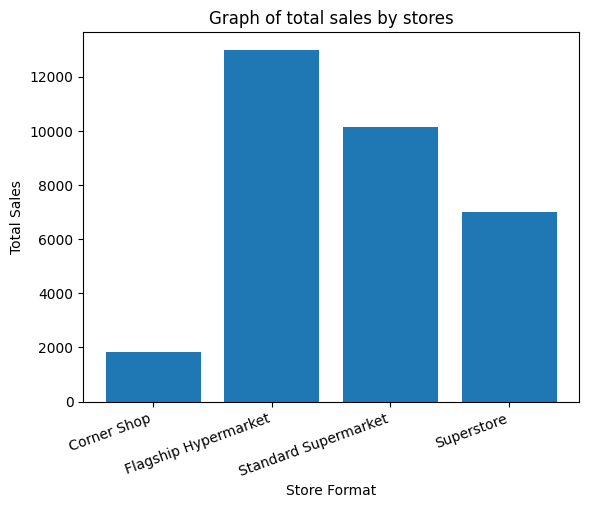

In [70]:
store_format_by_total_sales = train.groupby("store_format")["total_sales"].max()
# store_format_by_total_sales

index = store_format_by_total_sales.index
values = store_format_by_total_sales.values

plt.bar(index, values)
plt.xticks(
    ticks=range(len(index)),
    rotation=20,
    ha = "right"
)
plt.xlabel("Store Format")
plt.ylabel("Total Sales")
plt.title("Graph of total sales by stores")
plt.show()

In [71]:
# hiding this for now 
# train["shelf_visibility_bins"] = pd.qcut(train["shelf_visibility"], 5 )

In [72]:
# train_shelf_visibility_total_sales = train.groupby('shelf_visibility_bins')["total_sales"].max()

## Phase 3: Data Preprocessing 

In [73]:
def normalize_capitalization(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """'seafood' / 'SEAFOOD' / 'SeaFood' -> 'seafood', written into new_column."""
    df = df.copy()
    df[column] = df[column].astype(str).str.strip().str.lower()
    return df



def fit_weight_maps(train: pd.DataFrame, code_col="product_code", category_col="product_category",
                     weight_col="product_weight_kg", exclude_col="store_format",
                     exclude_val="Flagship Hypermarket"):
    """
    Flagship Hypermarket rows have no product_weight_kg at all, so they're excluded
    when computing the fill averages (they'd just contribute nothing but noise).
    Fit on train only; returns per-product-code means, per-category means, and an
    overall mean, to be applied to both train and test with apply_weight_fill.
    """
    reference = train[train[exclude_col] != exclude_val]
    code_map = reference.groupby(code_col)[weight_col].mean().round(3)
    category_map = reference.groupby(category_col)[weight_col].mean().round(3)
    overall_mean = round(reference[weight_col].mean(), 3)
    return code_map, category_map, overall_mean


def apply_weight_fill(df: pd.DataFrame, code_map, category_map, overall_mean,
                       code_col="product_code", category_col="product_category",
                       weight_col="product_weight_kg") -> pd.DataFrame:
    """Fills missing product_weight_kg: product_code mean -> category mean -> overall mean."""
    df = df.copy()
    filled = df[weight_col].fillna(df[code_col].map(code_map))
    still_na = filled.isna()
    filled.loc[still_na] = df.loc[still_na, category_col].map(category_map)
    still_na = filled.isna()
    filled.loc[still_na] = overall_mean
    df[weight_col] = filled
    return df


def overall_mode(df: pd.DataFrame, column: str):
    """
    calculates the overall mode
    Note: use on the train column
    """
    return df[column].mode()[0]


def apply_mode_fillna(df: pd.DataFrame, column: str, fill_value) -> pd.DataFrame:
    df = df.copy()
    df[column] = df[column].fillna(fill_value)
    return df

In [74]:
# 1. normalize capitalization first - pure per-row cleanup, no leakage either way
train = normalize_capitalization(train, "product_category")
test = normalize_capitalization(test, "product_category")

# 2. fit fill values on train only, apply to both
code_map, category_map, overall_mean = fit_weight_maps(train)
train = apply_weight_fill(train, code_map, category_map, overall_mean)
test = apply_weight_fill(test, code_map, category_map, overall_mean)

store_size_mode = overall_mode(train, "store_size")
train = apply_mode_fillna(train, "store_size", store_size_mode)
test = apply_mode_fillna(test, "store_size", store_size_mode)

check_nan_state(train, "train (post-clean)")

Percent values of NAN values in train (post-clean) dataframe 


,Column,Percent missing
0,id,0.0
1,product_code,0.0
2,product_weight_kg,0.0
3,fat_content,0.0
4,shelf_visibility,0.0
5,product_category,0.0
6,product_price,0.0
7,store_code,0.0
8,store_age_years,0.0
9,store_size,0.0


In [75]:
def encode_fat_content(df):
    """
    we encode the fat_content column since its just two cat columns
    """
    # df['encoded_fat_content'] = df["fat_content"].map({"Regular":1,"low fat":0}) # Another way to do the bellow function in one line
    # 0 = low fat
    # 1 = regular
    df = df.copy()
    df["encoded_fat_content"] = 0
    df.loc[df.fat_content == "Regular" , "encoded_fat_content"] = 1
    
    return df 

def encode_columns(df, columns_list):
    """
    explain this
    """
    df = df.copy()
    df = pd.get_dummies(df,columns = encode_column_list, drop_first = True, dtype = int)
    print(df.info())
    
    return df 

def encode_store_location_tier(df):
    """
    explain this
    """
    # this is an Ordinal data tier 1 is best to tier 3 worse
    # might use this for three-based models
    # 0 = tier one
    # 1 = tier two
    # 2 = tier three
    df = df.copy()
    df["encoded_store_location_tier"] = 0
    df.loc[df.store_location_tier == "Tier_2" , "encoded_store_location_tier"] = 1
    df.loc[df.store_location_tier == "Tier_3" , "encoded_store_location_tier"] = 2
    
    return df 

def encode_store_size(df):
    """
    explain this
    """
    # this is an Ordinal data 
    # might use this for three-based models
    # 0 = small
    # 1 = medium
    # 2 = large
    df = df.copy()
    df["encoded_store_size"] = 0
    df.loc[df.store_size == "Medium" , "encoded_store_size"] = 1
    df.loc[df.store_size == "Large" , "encoded_store_size"] = 2
    
    return df 

In [76]:
# feature_engineering columns taken from Abidemi's notebook


# Basic numeric interactions
def price_per_kg(df):    
    df["price_per_kg"] = (
        df["product_price"] /
        df["product_weight_kg"].replace(0, np.nan))
    
    return df

def price_visibility(df):
    df["price_visibility"] = (
        df["product_price"] * df["shelf_visibility"])

    return df

def price_squared(df):
    df["price_squared"] = df["product_price"] ** 2
    df["visibility_squared"] = df["shelf_visibility"] ** 2
    df["store_age_squared"] = df["store_age_years"] ** 2

    return df 


# Product/store categorical interactions
def product_store(df):
    df["product_store"] = (
        df["product_code"].astype("string")
        + "__"
        + df["store_code"].astype("string"))
    return df 

def product_format(df):
    df["product_format"] = (
        df["product_code"].astype("string")
        + "__"
        + df["store_format"].astype("string"))
    
    return df

def product_category_format(df):
    df["product_category_format"] = (
        df["product_category"].astype("string")
        + "__"
        + df["store_format"].astype("string"))
    
    return df

def category_store(df):
    df["category_store"] = (
        df["product_category"].astype("string")
        + "__"
        + df["store_code"].astype("string"))
    return df 

def store_tier_format(df):
    df["store_tier_format"] = (
        df["store_location_tier"].astype("string")
        + "__"
        + df["store_format"].astype("string"))
        
    return df 

def feature_eng(df):
    """
    Main feature engineering function
    """
    df = df.copy()
    
    print(f"{'>'*2} Engineering Numerical columns {'<'*2}")
    
    print(f"{"-" * 15} calculating the price per kg ratio {"-" * 15}")
    df = price_per_kg(df)
    print(f"{"-" * 15} calculating the price visibility {"-" * 15}")
    df = price_visibility(df)
    print(f"{"-" * 15} calculating the price squared {"-" * 15}")
    df = price_squared(df)

    print(f"{'>'*2} Engineering Categorical columns {'<'*2}")
    
    print(f"{"-" * 15} Engineering product_code and store code interactions {"-" * 15}")
    df = product_store(df)
    print(f"{"-" * 15} Engineering product_code and store format interactions {"-" * 15}")
    df = product_format(df)
    print(f"{"-" * 15} Engineering product category and store format interactions {"-" * 15}")
    df = product_category_format(df)
    print(f"{"-" * 15} Engineering product category and store code interactions {"-" * 15}")
    df = category_store(df)
    print(f"{"-" * 15} Engineering store_location_tier and store format interactions {"-" * 15}")
    df = store_tier_format(df)
    
    return df 
    


In [77]:
drop_column_list = ["id","product_code"] #, "store_code" have values 
encode_column_list = ["product_category","store_format","store_code", "fat_content","store_size","store_location_tier"]


# check out using log1 for transform_sales product_category_format
def clean_df(df, drop_column_list, encode_column_list, code_map, category_map, overall_mean):
    """
    Combining all those functions to a simple pipeline to clean a dataframe
    """
    df = df.copy()
    # print(f"{"*" * 15} normalizing the inconsistent capitalizations{"*" * 15}")
    # df = normalize_capitalization(df, "product_category", "cleaned_product_category")
    print(f"{"*" * 15} filling the nan values in product_weight_kg column{"*" * 15}")
    df = apply_weight_fill(df, code_map, category_map, overall_mean)
    
    print(f"{"+" * 15} Feature engineering starting {"+" * 15}")
    df = feature_eng(df) 
    print(f"{"+" * 15} Feature engineering Done {"+" * 15}")    
    print(f"{"*" * 15} droping un-needed columns{"*" * 15}")
    df = df.drop(columns = drop_column_list)

    return df 
    

In [78]:
# Fit once on train - outside of the clean_df function for a reason 
CAT_FEATURES = ['product_category', 'store_format', 'store_code', 'fat_content', 'store_size', 'store_location_tier',"store_tier_format","category_store","product_category_format","product_format","product_store"]

code_map, category_map, overall_mean = fit_weight_maps(train)
trainX = clean_df(train, drop_column_list, encode_column_list, code_map, category_map, overall_mean)

*************** filling the nan values in product_weight_kg column***************
+++++++++++++++ Feature engineering starting +++++++++++++++
>> Engineering Numerical columns <<
--------------- calculating the price per kg ratio ---------------
--------------- calculating the price visibility ---------------
--------------- calculating the price squared ---------------
>> Engineering Categorical columns <<
--------------- Engineering product_code and store code interactions ---------------
--------------- Engineering product_code and store format interactions ---------------
--------------- Engineering product category and store format interactions ---------------
--------------- Engineering product category and store code interactions ---------------
--------------- Engineering store_location_tier and store format interactions ---------------
+++++++++++++++ Feature engineering Done +++++++++++++++
*************** droping un-needed columns***************


## Phase 4: Spliting the train dataframe 
we split the train_data into train and validation

test the validation against the kaggle score an up in the validation should be an up on the kaggle score 
then we use the spit for experimentation and testing- (might use mlflow to track experiments)

In [79]:
target = "total_sales"
train_y = trainX[target]
train_X = trainX.drop(columns = target)
# using 0.3 for now thats about 2045 rows for validation my switch to cross-validation later
train_dfX, val_dfX, train_dfy, val_dfy = train_test_split(train_X, train_y, test_size = 0.3, random_state = 43)

In [80]:
basic_data(train_dfX, "train_df X")
basic_data(train_dfy, "train_df y", for_y = 1)
basic_data(val_dfX, "validation_df X")
basic_data(val_dfy, "validation_df y", for_y = 1)

The train_df X dataframe has 4772 Rows and 20 Columns
******************************
The train_df y dataframe has 4772 Rows
******************************
The validation_df X dataframe has 2046 Rows and 20 Columns
******************************
The validation_df y dataframe has 2046 Rows
******************************


In [81]:
## transform the target column here 
def log1p(series):
    series = np.log1p(series)

    return series

def sqrt(series):
    series = np.sqrt(series)

    return series 

def convert_back(series):
    # series = np.expm1(series) # for log1p()
    series = np.square(series) # for sqrt
    
    return series

### Phase 5: Fitting the model 
comparing linear regression model, random forest regressor and xgboost regressor

In [82]:
def compute_metric(y_true, y_pred, name):
    
    rmse_val = round(root_mean_squared_error(y_true, y_pred), 5)
    mae_val = round(mean_absolute_error(y_true, y_pred), 5)
    rmse_name = f"{name} rmse"
    mae_name = f"{name} mae"
    
    print(f"{rmse_name}: {rmse_val}")
    print(f"{mae_name}: {mae_val}")

    return rmse_val, rmse_name, mae_val, mae_name

In [83]:
# target_transformed
def fit_score(train_X, train_y,val_X, val_y, model,model_name, note_for_tag: dict, params = None, target_transformed = False):
    
    model.fit(train_X, train_y)
    
    # Predict on the test set, compute and log the loss metric
    model_pred = model.predict(val_X)
    
    if target_transformed == True:
        # convert the transformed predicted value back for metric
        model_pred = convert_back(model_pred)
    
    rmse_metric_value, rmse_metric_name, mae_metric_value, mae_metric_name  = compute_metric(val_y, model_pred, model_name)

In [84]:
# without sqrt calculations

catgbmodel = CatBoostRegressor(bagging_temperature=0.8355435902118089, border_count=142, cat_features=CAT_FEATURES, depth=4,
                 iterations=700, l2_leaf_reg=0.1254770954495214, learning_rate=0.03199074467948488,loss_function='RMSE', random_seed=43, random_strength=0.35945610594606736, verbose=False)
model_name = "catgbregressor0-1-1_target_transform_test"
note_for_tag = {"name":"catgbregressor test","tag":"target_transform_test"}
fit_score(train_dfX, train_dfy, val_dfX, val_dfy,  catgbmodel, model_name, note_for_tag)

catgbregressor0-1-1_target_transform_test rmse: 1088.13306
catgbregressor0-1-1_target_transform_test mae: 755.43016


In [85]:
train_dfy_sqrt = sqrt(train_dfy)

catgbmodel = CatBoostRegressor(bagging_temperature=0.8355435902118089, border_count=142, cat_features=CAT_FEATURES, depth=4,
                 iterations=700, l2_leaf_reg=0.1254770954495214, learning_rate=0.03199074467948488,loss_function='RMSE', random_seed=43, random_strength=0.35945610594606736, verbose=False)
model_name = "catgbregressor0-1-1_target_transform_test"
note_for_tag = {"name":"catgbregressor test","tag":"target_transform_test"}
fit_score(train_dfX, train_dfy_sqrt, val_dfX, val_dfy,  catgbmodel, model_name, note_for_tag, target_transformed = True)

catgbregressor0-1-1_target_transform_test rmse: 1080.53908
catgbregressor0-1-1_target_transform_test mae: 743.11427


In [86]:
def objective(trial, X, y, cat_features, n_splits=5, seed=RANDOM_SEED):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 2000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_seed": seed,
        "loss_function": "RMSE",
        "verbose": False,
    }

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_rmses = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params, early_stopping_rounds=50)
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            cat_features=cat_features,
            verbose=False,
        )

        preds = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, preds)
        fold_rmses.append(rmse)

    return np.mean(fold_rmses)


def tune_catboost(X, y, cat_features, n_trials=50, n_splits=5, seed=RANDOM_SEED, direction="minimize"):
    """
    Runs Optuna hyperparameter search using K-fold CV RMSE as the objective.
    cat_features: list of column names (or indices) that are categorical —
    pass these RAW/unencoded, CatBoost handles them internally.
    Returns the fitted study — study.best_params gives the winning config.
    """
    study = optuna.create_study(direction=direction, sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(lambda trial: objective(trial, X, y, cat_features, n_splits=n_splits, seed=seed),
                    n_trials=n_trials, show_progress_bar=True)

    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)

    return study

In [87]:
# uncomment if you want to run the Optuna tuning hyperparameter analysis 
# yy = trainX["total_sales"]

# y = sqrt(yy)
# X = trainX.drop(columns = ["total_sales"])

# study = tune_catboost(X, y, cat_features=CAT_FEATURES, n_trials=50, n_splits=5)

# best_params = study.best_params

In [88]:
# Also Uncomment this 
# tunned_catboost_model = CatBoostRegressor(**best_params, cat_features=CAT_FEATURES, verbose=False, random_seed=RANDOM_SEED)

# model_name = "catboost_optuna tuned"
# note_for_tag = {"name":"catgbregressor optuna-tuned","tag":"Optuna-tuned"}
# fit_score(train_dfX, train_dfy, val_dfX, val_dfy,  tunned_catboost_model, model_name, note_for_tag)

In [89]:
# better score  1077 keep in mind better than my best solution
catboost_available = True

try:
    from catboost import CatBoostRegressor
except ImportError:
    catboost_available = False
    print("CatBoost is not installed in this environment.")

if catboost_available:
    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=2500,
        learning_rate=0.035,
        depth=8,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=250,
        allow_writing_files=False
    )

    #train_dfX, train_dfy, val_dfX, val_dfy
    val_dfy_sqrt = sqrt(val_dfy)
    
    cat_model.fit(
        train_dfX,
        train_dfy_sqrt,
        cat_features=CAT_FEATURES,
        eval_set=(val_dfX, val_dfy_sqrt),
        use_best_model=True,
        early_stopping_rounds=200
    )

    cat_pred = cat_model.predict(val_dfX)
    cat_pred = convert_back(cat_pred)
    rmse = root_mean_squared_error(val_dfy, cat_pred)
    mae = mean_absolute_error(val_dfy, cat_pred)

    print("Best iteration:", cat_model.get_best_iteration())
    print(f"Rmse:{rmse} mae: {mae}")

0:	learn: 17.9466787	test: 17.8960713	best: 17.8960713 (0)	total: 19.4ms	remaining: 48.4s
250:	learn: 9.7965343	test: 10.5256815	best: 10.5227076 (226)	total: 3.77s	remaining: 33.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 10.52270758
bestIteration = 226

Shrink model to first 227 iterations.
Best iteration: 226
Rmse:1077.5428685345987 mae: 740.3701752545196


## Phase 6: fitting for the kaggle leaderboard

In [90]:
trainX.info()
yy = trainX["total_sales"]

y = sqrt(yy)
X = trainX.drop(columns = ["total_sales"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_weight_kg        6818 non-null   float64
 1   fat_content              6818 non-null   object 
 2   shelf_visibility         6818 non-null   float64
 3   product_category         6818 non-null   object 
 4   product_price            6818 non-null   float64
 5   store_code               6818 non-null   object 
 6   store_age_years          6818 non-null   int64  
 7   store_size               6818 non-null   object 
 8   store_location_tier      6818 non-null   object 
 9   store_format             6818 non-null   object 
 10  total_sales              6818 non-null   float64
 11  price_per_kg             6818 non-null   float64
 12  price_visibility         6818 non-null   float64
 13  price_squared            6818 non-null   float64
 14  visibility_squared      

In [91]:
# using the code_map, category_map, and overall_mean of train
testX = clean_df(test, drop_column_list, encode_column_list, code_map, category_map, overall_mean)

*************** filling the nan values in product_weight_kg column***************
+++++++++++++++ Feature engineering starting +++++++++++++++
>> Engineering Numerical columns <<
--------------- calculating the price per kg ratio ---------------
--------------- calculating the price visibility ---------------
--------------- calculating the price squared ---------------
>> Engineering Categorical columns <<
--------------- Engineering product_code and store code interactions ---------------
--------------- Engineering product_code and store format interactions ---------------
--------------- Engineering product category and store format interactions ---------------
--------------- Engineering product category and store code interactions ---------------
--------------- Engineering store_location_tier and store format interactions ---------------
+++++++++++++++ Feature engineering Done +++++++++++++++
*************** droping un-needed columns***************


In [92]:
kaggle_lr = catgbmodel = CatBoostRegressor(bagging_temperature=0.8355435902118089, border_count=142, cat_features=CAT_FEATURES, depth=4,
                 iterations=700, l2_leaf_reg=0.1254770954495214, learning_rate=0.03199074467948488,loss_function='RMSE', random_seed=43, random_strength=0.35945610594606736, verbose=False)

kaggle_lr.fit(X, y)

kaggle_pred = kaggle_lr.predict(testX)
kaggle_pred = convert_back(kaggle_pred)

In [93]:
kaggle_pred.shape

(1705,)

In [94]:
sample_df = sample

sample_df["total_sales"] = kaggle_pred.round(2)

In [95]:
sample_df.to_csv("catboost_submission.csv", index=False)

In [96]:
sample_df.head()

,id,total_sales
0,row_00009,2594.98
1,row_00015,4336.66
2,row_00019,3002.02
3,row_00020,3187.67
4,row_00023,2319.65


### local val to kaggle public checking 
- catboost model local validation - 1080 to kaggle public val - 1086